# Cleavage-potential reduction: scale comparison

`CleavagePotential` now exposes a `reduction` argument that controls how the
per-bond, per-protease susceptibility scores collapse into a single number
$\Phi_{cleav}$. It is orthogonal to `variant` (`product` / `additive` /
`meanfield`), which only sets the scoring math.

| `reduction` | formula | meaning |
| --- | --- | --- |
| `"sum"` (default) | $\sum_\pi \rho_\pi(\cdot)$ | weighted sum over the **whole panel** and all bonds (original behaviour) |
| `"max_protease"` | $\max_\pi \rho_\pi(\cdot)$ | only the single **dominant (most aggressive) protease**; bonds still combined per `variant` |
| `"max_cut"` | $\max_\pi \max_b \rho_\pi R(\pi,b)$ | the single **most-likely cut event** (max over proteases *and* bonds) |

Because `"sum"` mixes contributions across every protease and every bond, its
magnitude scales with panel size and peptide length, whereas the two `max_*`
modes stay on the scale of a single protease/bond. This notebook quantifies
that difference on real DBAASP peptides.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()

# Root that holds the source tree (for imports).
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "src" / "pep_compass").is_dir()),
    cwd,
)
sys.path.insert(0, str(project_root / "src"))

# `data/` and `results/` are gitignored and may live in a sibling checkout
# (e.g. the main `pep-compass` repo) rather than this worktree.
candidate_roots = [project_root, *project_root.parents]
candidate_roots += list((project_root.parent).glob("pep-compass*"))


def _find(rel: str) -> Path | None:
    seen = set()
    for root in candidate_roots:
        if root in seen:
            continue
        seen.add(root)
        candidate = root / rel
        if candidate.exists():
            return candidate
    return None


MEROPS_ROOT = _find(Path("data") / "merops")
ALL_IN_CSV = _find(Path("results") / "data" / "all_in" / "peptides_apex.csv")

MEROPS_DATASETS = (7,)          # S. aureus panel (several proteases)
VARIANTS = ("product", "additive", "meanfield")
REDUCTIONS = ("sum", "max_protease", "max_cut")
N_SAMPLE = 400
DEVICE = "cpu"
RNG = np.random.default_rng(0)

print("project_root:", project_root)
print("MEROPS_ROOT :", MEROPS_ROOT)
print("ALL_IN_CSV  :", ALL_IN_CSV)

project_root: C:\Users\Karol\Desktop\PepCompass\pep-compass-notebooks
MEROPS_ROOT : C:\Users\Karol\Desktop\PepCompass\pep-compass\data\merops
ALL_IN_CSV  : C:\Users\Karol\Desktop\PepCompass\pep-compass\results\data\all_in\peptides_apex.csv


In [2]:
from pep_compass.optimization.components.helpers.proteolysis import (
    CleavagePotential,
    load_protease_panel,
)

panel = load_protease_panel(MEROPS_DATASETS, merops_root=MEROPS_ROOT, device=DEVICE)
n_proteases = len(panel.codes)
print(f"panel: {n_proteases} proteases from datasets {MEROPS_DATASETS}")

if ALL_IN_CSV is not None:
    raw = pd.read_csv(ALL_IN_CSV, usecols=["sequence", "dataset"])
    dbaasp = (
        raw[raw["dataset"].str.contains("dbaasp", case=False, na=False)]
        .drop_duplicates(subset=["sequence"])
        .reset_index(drop=True)
    )
    sequences = dbaasp["sequence"].tolist()
else:
    # Fallback synthetic set so the notebook is runnable without the CSV.
    aa = list("ACDEFGHIKLMNPQRSTVWY")
    sequences = [
        "".join(RNG.choice(aa, size=int(RNG.integers(10, 26)))) for _ in range(2000)
    ]

if len(sequences) > N_SAMPLE:
    idx = RNG.choice(len(sequences), size=N_SAMPLE, replace=False)
    sequences = [sequences[i] for i in idx]

lengths = np.array([len(s) for s in sequences])
print(f"{len(sequences)} peptides | length {lengths.min()}-{lengths.max()}")

panel: 55 proteases from datasets (7,)


400 peptides | length 10-25


In [3]:
# Evaluate every (variant, reduction) combination on the same peptides.
records = {}
for variant in VARIANTS:
    for reduction in REDUCTIONS:
        pot = CleavagePotential(
            panel, variant=variant, reduction=reduction, device=DEVICE
        )
        phi = pot.sequence_log_potential(sequences).cpu().numpy()
        records[(variant, reduction)] = phi

df = pd.DataFrame({f"{v}/{r}": records[(v, r)] for v in VARIANTS for r in REDUCTIONS})
df.insert(0, "length", lengths)
df.head()

,length,product/sum,product/max_protease,product/max_cut,additive/sum,additive/max_protease,additive/max_cut,meanfield/sum,meanfield/max_protease,meanfield/max_cut
0,16,-15.861320,-16.156908,-16.216751,-20736.128906,-356.088043,-16.216751,-1185.271973,-16.156942,-16.216751
1,18,-17.278238,-19.475927,-20.115063,-23668.681641,-405.440613,-20.115063,-1192.648193,-19.491045,-20.115063
2,21,-16.976641,-18.668129,-20.091703,-28344.369141,-458.640869,-20.299620,-1222.399780,-18.750004,-20.299620
3,16,-16.002691,-17.781904,-18.471581,-20105.423828,-336.302094,-18.556204,-1141.545898,-17.813032,-18.556204
4,13,-17.073399,-18.779585,-18.872671,-16543.359375,-286.462219,-18.872671,-1190.705444,-18.780727,-18.872671


## 1. Scale of $\Phi_{cleav}$ per reduction

The summary below makes the scaling explicit: for a fixed `variant`, `"sum"`
aggregates over the whole panel and all bonds, so its magnitude is much larger
(more extreme) than the two `max_*` modes, which stay on the scale of a single
protease / bond.

In [4]:
summary = df.drop(columns="length").describe().T[
    ["mean", "std", "min", "50%", "max"]
]
summary["abs_mean"] = df.drop(columns="length").abs().mean().values
summary.round(3)

,mean,std,min,50%,max,abs_mean
product/sum,-16.770,0.729,-18.368,-16.753,-13.994,16.770000
product/max_protease,-18.627,1.296,-21.495,-18.638,-14.254,18.627001
product/max_cut,-19.112,1.400,-22.478,-19.117,-14.607,19.112000
additive/sum,-21305.926,5876.693,-33303.109,-20963.824,-12173.212,21305.925781
additive/max_protease,-358.800,100.775,-573.074,-355.661,-189.557,358.799988
additive/max_cut,-19.225,1.436,-22.478,-19.269,-14.607,19.225000
meanfield/sum,-1188.312,33.844,-1286.735,-1188.344,-1118.871,1188.312012
meanfield/max_protease,-18.742,1.327,-21.496,-18.809,-14.273,18.742001
meanfield/max_cut,-19.225,1.436,-22.478,-19.269,-14.607,19.225000


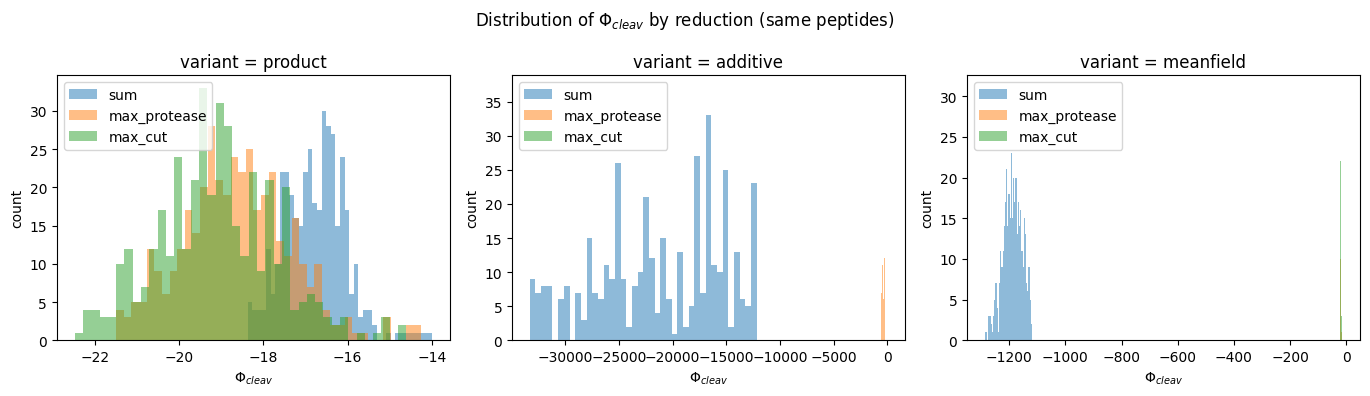

In [5]:
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4.6 * len(VARIANTS), 4.0))
for ax, variant in zip(axes, VARIANTS):
    for reduction in REDUCTIONS:
        ax.hist(
            df[f"{variant}/{reduction}"],
            bins=40,
            alpha=0.5,
            label=reduction,
        )
    ax.set_title(f"variant = {variant}")
    ax.set_xlabel(r"$\Phi_{cleav}$")
    ax.set_ylabel("count")
    ax.legend()
fig.suptitle("Distribution of $\\Phi_{cleav}$ by reduction (same peptides)")
fig.tight_layout()
plt.show()

## 2. Do the reductions rank peptides the same way?

Even though the absolute scales differ, a stability *filter* only cares about
the ranking. Below is the Spearman rank correlation between reductions (for the
`product` variant) and a scatter of `sum` vs the two `max_*` modes. High rank
correlation means switching to `max_*` mostly rescales the axis; low
correlation means it re-orders peptides (a genuinely different objective).

Spearman rank correlation (product variant):
                sum  max_protease  max_cut
sum           1.000         0.917    0.874
max_protease  0.917         1.000    0.965
max_cut       0.874         0.965    1.000


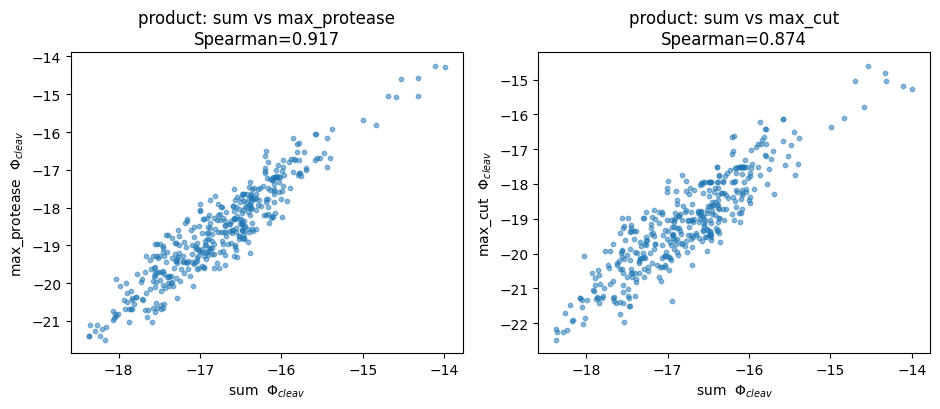

In [6]:
prod = df[[f"product/{r}" for r in REDUCTIONS]]
prod.columns = list(REDUCTIONS)
spearman = prod.corr(method="spearman")
print("Spearman rank correlation (product variant):")
print(spearman.round(3))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
for ax, reduction in zip(axes, ("max_protease", "max_cut")):
    ax.scatter(prod["sum"], prod[reduction], s=10, alpha=0.5)
    ax.set_xlabel(r"sum  $\Phi_{cleav}$")
    ax.set_ylabel(rf"{reduction}  $\Phi_{{cleav}}$")
    ax.set_title(f"product: sum vs {reduction}\nSpearman={spearman.loc['sum', reduction]:.3f}")
fig.tight_layout()
plt.show()

## Takeaways

- **Scale.** `"sum"` is the most extreme because it accumulates every
  protease and every bond; `"max_protease"` and `"max_cut"` are bounded by a
  single enzyme / bond and are therefore far less negative and roughly
  length-independent.
- **`max_protease` vs `max_cut`.** `max_cut` is the strictest (single strongest
  cut of the single strongest enzyme); `max_protease` keeps that enzyme's full
  bond aggregation.
- **Ranking.** Where the Spearman correlation is high, the `max_*` modes are a
  cleaner-scaled proxy for the panel sum; where it is lower, they encode a
  genuinely different "weakest-link" stability objective (a specific protease
  dominating) rather than a panel-average one.

Pick the reduction when building the potential, e.g.
`build_clasp_potential(..., reduction="max_protease")`.